In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [2]:
amount_by_school = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)

total_uva_aid = df.loc[df['Institution Name'] == 'University of Virginia']['Foreign Gift Amount'].sum()
upper_lim = total_uva_aid * 1.1
lower_lim = total_uva_aid * 0.9

schools_in_class = amount_by_school.loc[(amount_by_school > lower_lim) & (amount_by_school < upper_lim)]

schools_in_class

Institution Name
Colorado State University                23985191
Washington State University              23975181
North Carolina State University          23762788
University of Alabama                    23626197
California State University, East Bay    23308003
University of Wisconsin - Madison        22945761
University of Virginia                   22189238
Drexel University                        21828454
University of Illinois at Chicago        21123098
Chapman University                       20956280
Teachers College, Columbia University    20817997
Johnson & Wales University               20762643
Name: Foreign Gift Amount, dtype: int64

Text(0.5, 1.0, 'Schools with Foreign Gift Amounts within 10% of UVA')

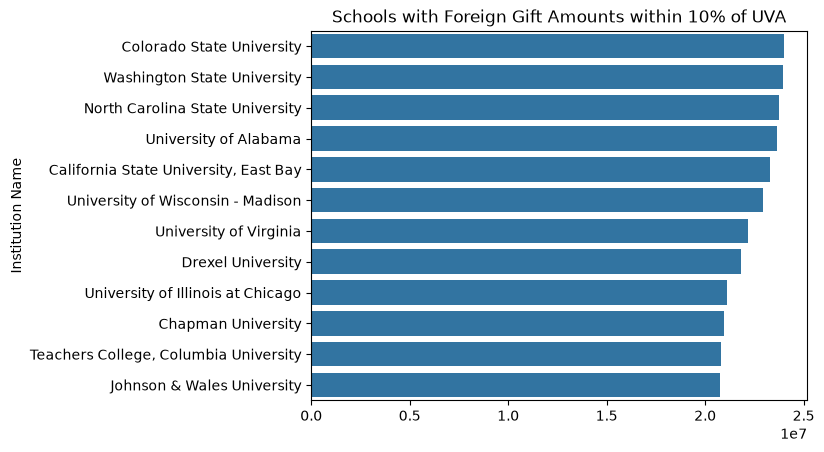

In [3]:
sns.barplot(x=schools_in_class.values, y=schools_in_class.index)
plt.title('Schools with Foreign Gift Amounts within 10% of UVA')

* schools in UVA's class

In [4]:
df_schools_in_class = df.loc[df['Institution Name'].isin(schools_in_class.index)]

df_schools_in_class.groupby('Institution Name')['Country of Giftor'].nunique().sort_values(ascending=False)

Institution Name
University of Wisconsin - Madison        16
Colorado State University                15
University of Virginia                   15
University of Illinois at Chicago        12
Teachers College, Columbia University    10
North Carolina State University          10
Drexel University                         9
Washington State University               9
University of Alabama                     7
California State University, East Bay     4
Chapman University                        3
Johnson & Wales University                1
Name: Country of Giftor, dtype: int64

* In its class, UVA has the third most diverse set of countries giving aid. This is good to support the argument that UVA gets money from diverse sources.

In [5]:
uva_obs = df[df['Institution Name'] == 'University of Virginia']

In [6]:
uva_obs.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)

Country of Giftor
BANGLADESH     4228589
SWEDEN         4007552
TANZANIA       2776447
SWITZERLAND    2000000
ENGLAND        1950666
GUERNSEY       1500000
FINLAND        1008384
BERMUDA         900000
KOREA           862787
SINGAPORE       805000
Name: Foreign Gift Amount, dtype: int64

* Bangladesh gives the most money to UVA

In [7]:
uva_obs.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)

Giftor Name
AstraZeneca                            3208048
Intrnl Centre Diarrheal Disease        1382896
Haydom Lutheran Hospital d/b/a Hayd    1100553
Haydom Luther Hospital                 1035339
Harvest Group Holding                  1000000
Lawrence D/ Karin S Howell             1000000
Lawrence D & Karin S Howell            1000000
Danisco Sweeteners Oy                   990331
Intnl Centre for Diarrhoeal Disease     919857
International Centre for Diarrhoeal     919518
Name: Foreign Gift Amount, dtype: int64

* Astrazeneca is the coorporation that gives the most to UVA

In [8]:
import plotly.graph_objects as go

# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

df = uva_obs

giftor = 'Giftor Name'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

* Visual showing company flows into UVA

In [9]:
import plotly.graph_objects as go

# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

df = uva_obs

giftor = 'Country of Giftor'
recipi = 'Giftor Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()

* Visual showing what country is behind the largest coorporations feeding into UVA. Bangladesh is single largest country that contributes, but it does it through several different funds.